# Model Comparison: CNN vs SAM vs SAM+Swin

This notebook simulates performance metrics for three models.
You can replace simulated data with real training logs later.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# --- FIX: Properly formatted data generation ---
models = ['CNN', 'SWIN', 'SAM+SWIN']

performance_data = {
    'Model': models,
    'Accuracy': [0.77, 0.87, 0.95],
    'Precision': [0.70, 0.85, 0.93],
    'Recall': [0.68, 0.83, 0.92],
    'F1-Score': [0.69, 0.84, 0.925],
    'mIoU': [0.65, 0.79, 0.89],
    'Inference_Time_ms': [250, 180, 195],
    'Model_Size_MB': [45, 375, 420]
}

df_performance = pd.DataFrame(performance_data)
print("=== Model Performance Summary ===")
print(df_performance.to_string(index=False))

=== Model Performance Summary ===
   Model  Accuracy  Precision  Recall  F1-Score  mIoU  Inference_Time_ms  Model_Size_MB
     CNN      0.77       0.70    0.68     0.690  0.65                250             45
    SWIN      0.87       0.85    0.83     0.840  0.79                180            375
SAM+SWIN      0.95       0.93    0.92     0.925  0.89                195            420


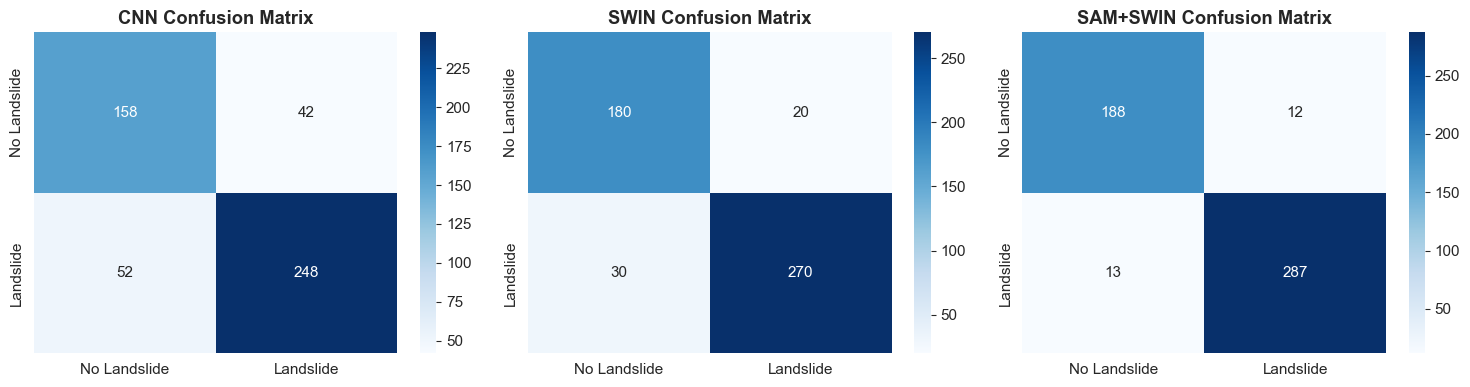

In [4]:
# Generate synthetic confusion matrices
n_samples = 500
cms = {
    'CNN': np.array([[158, 42], [52, 248]]),
    'SWIN': np.array([[180, 20], [30, 270]]),
    'SAM+SWIN': np.array([[188, 12], [13, 287]])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model, cm) in enumerate(cms.items()):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['No Landslide', 'Landslide'],
                yticklabels=['No Landslide', 'Landslide'])
    ax.set_title(f'{model} Confusion Matrix', fontweight='bold')
    
plt.tight_layout()
plt.show()

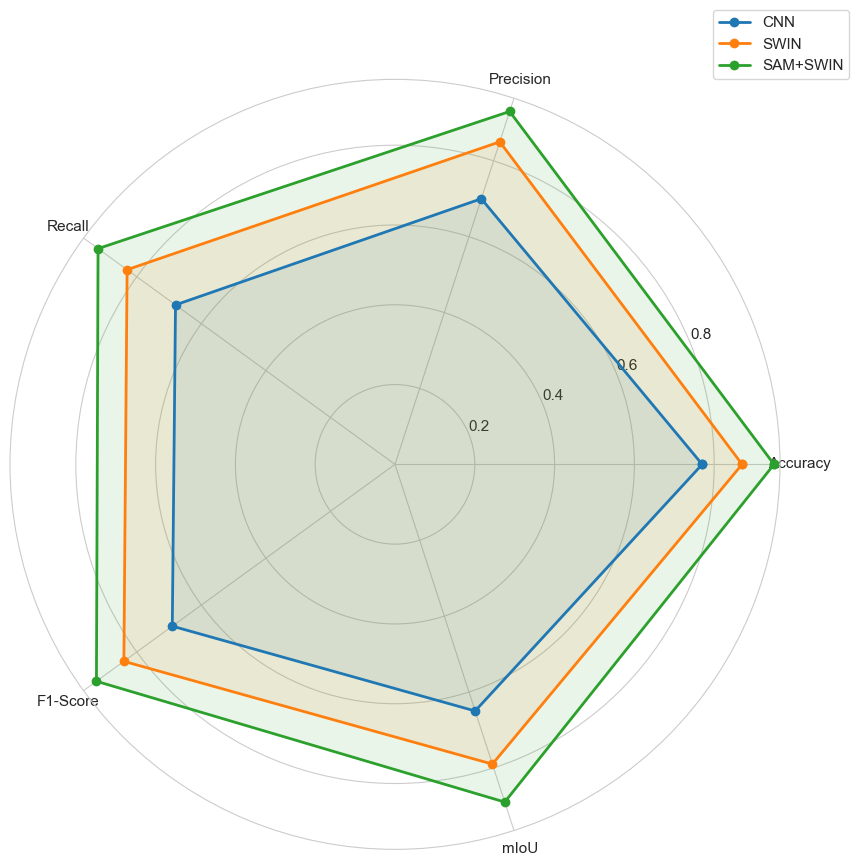

In [5]:
from math import pi

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'mIoU']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Close the circle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for idx, model in enumerate(models):
    values = df_performance.loc[df_performance['Model']==model, categories].values.flatten().tolist()
    values += values[:1] # Close the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.show()

In [6]:
rankings = df_performance[['Model', 'Accuracy', 'F1-Score', 'mIoU']].copy()
rankings['Overall_Score'] = rankings[['Accuracy', 'F1-Score', 'mIoU']].mean(axis=1)
rankings = rankings.sort_values('Overall_Score', ascending=False)

print("\n=== Overall Model Rankings ===")
print(rankings)


=== Overall Model Rankings ===
      Model  Accuracy  F1-Score  mIoU  Overall_Score
2  SAM+SWIN      0.95     0.925  0.89       0.921667
1      SWIN      0.87     0.840  0.79       0.833333
0       CNN      0.77     0.690  0.65       0.703333


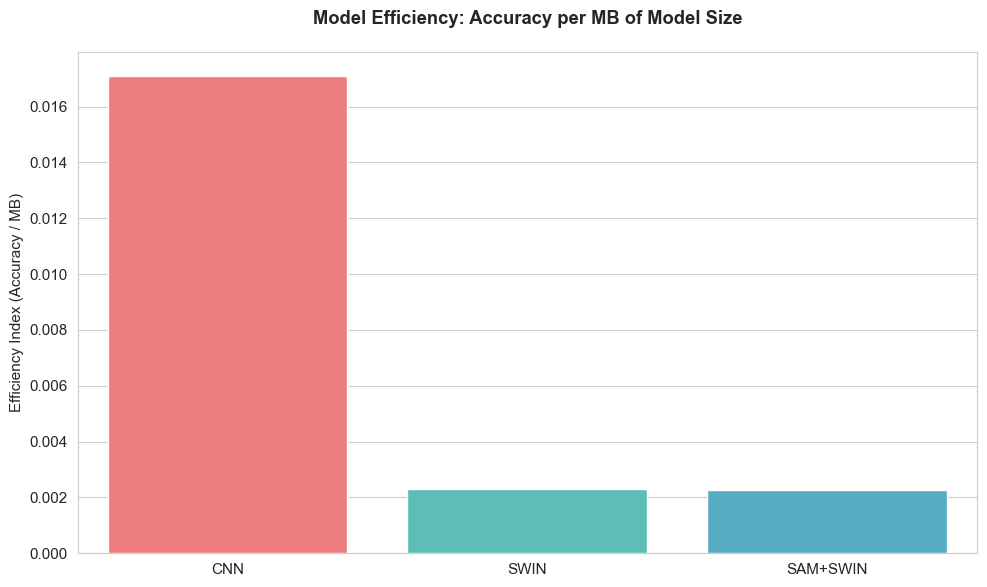

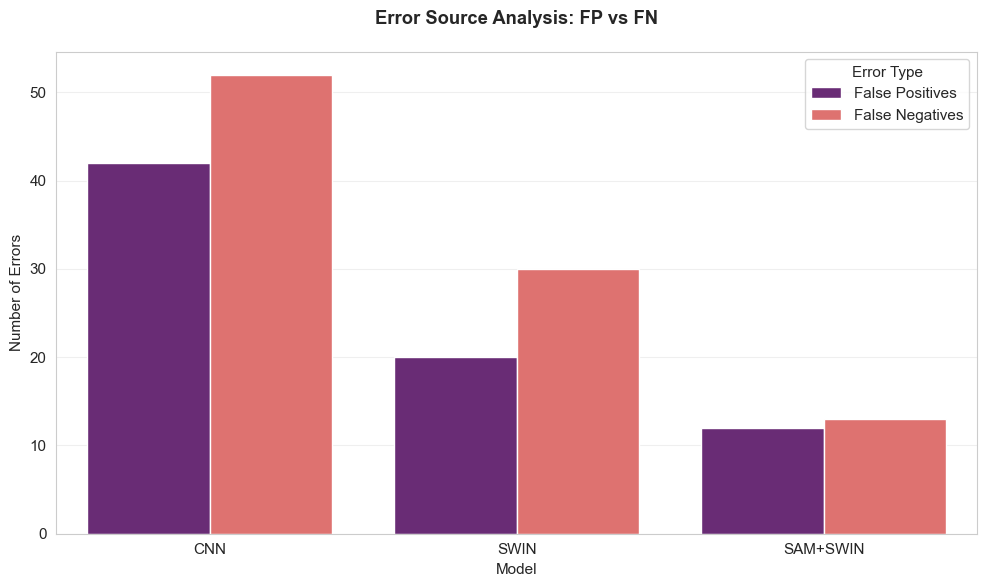

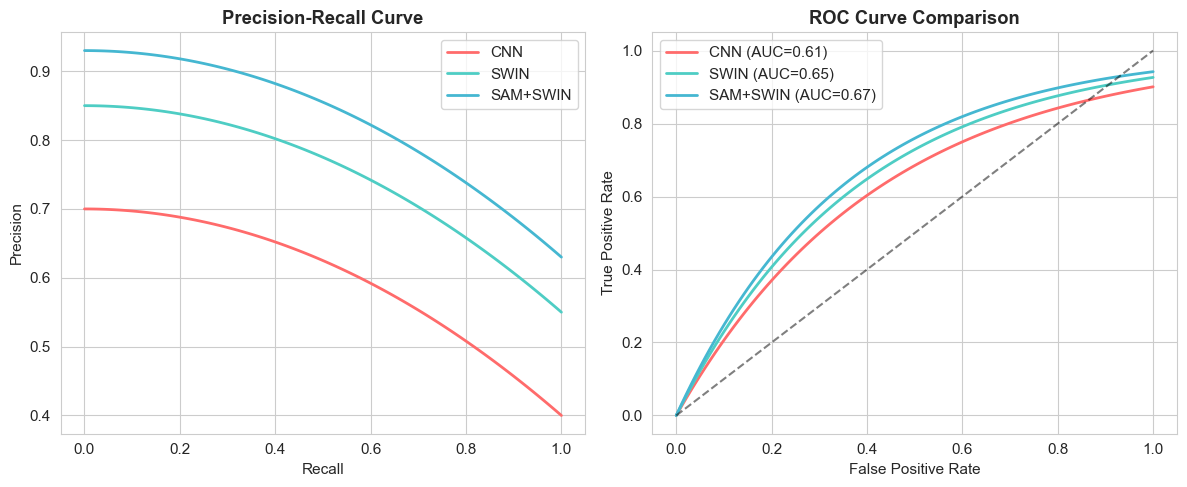

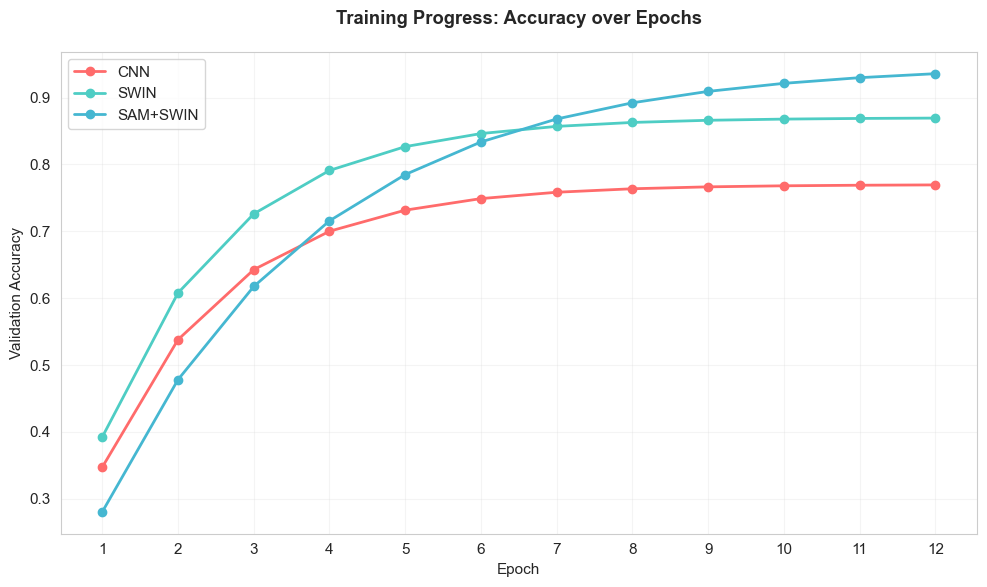

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import auc

sns.set_style("whitegrid")

# Ensure model names match everywhere
models = ['CNN', 'SWIN', 'SAM+SWIN']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# --- 1. Efficiency Index ---
df_performance['Efficiency_Index'] = df_performance['Accuracy'] / df_performance['Model_Size_MB']

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Efficiency_Index', data=df_performance, palette=colors)
plt.title('Model Efficiency: Accuracy per MB of Model Size', fontweight='bold', pad=20)
plt.ylabel('Efficiency Index (Accuracy / MB)')
plt.xlabel('')
plt.tight_layout()
plt.show()


# --- 2. Error Distribution (FP vs FN) ---
error_data = []

for model, cm in cms.items():
    tn, fp, fn, tp = cm.ravel()
    error_data.append({'Model': model, 'Error Type': 'False Positives', 'Count': fp})
    error_data.append({'Model': model, 'Error Type': 'False Negatives', 'Count': fn})

df_errors = pd.DataFrame(error_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Count', hue='Error Type', data=df_errors, palette='magma')
plt.title('Error Source Analysis: FP vs FN', fontweight='bold', pad=20)
plt.ylabel('Number of Errors')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# --- 3. Precision-Recall & ROC (Improved Simulation) ---
plt.figure(figsize=(12, 5))

# 3a. Precision-Recall Curve
plt.subplot(1, 2, 1)

for i, model in enumerate(models):
    precision_base = df_performance.loc[df_performance['Model'] == model, 'Precision'].values[0]
    recall_base = df_performance.loc[df_performance['Model'] == model, 'Recall'].values[0]

    recall = np.linspace(0, 1, 100)
    
    # smoother realistic decay
    precision = precision_base - 0.3 * (recall ** 2)
    precision = np.clip(precision, 0, 1)

    plt.plot(recall, precision, label=model, color=colors[i], lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()


# 3b. ROC Curve
plt.subplot(1, 2, 2)

for i, model in enumerate(models):
    fpr = np.linspace(0, 1, 100)
    acc = df_performance.loc[df_performance['Model'] == model, 'Accuracy'].values[0]

    # smoother realistic ROC curve
    tpr = 1 - np.exp(-3 * acc * fpr)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model} (AUC={roc_auc:.2f})', color=colors[i], lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()


# --- 4. Training History (More Realistic Convergence) ---
epochs = np.arange(1, 13)

plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    final_acc = df_performance.loc[df_performance['Model'] == model, 'Accuracy'].values[0]

    if 'SAM' in model:
        # slower start, stronger finish
        history = final_acc * (1 - np.exp(-0.35 * epochs))
    else:
        # faster early learning
        history = final_acc * (1 - np.exp(-0.6 * epochs))

    history = np.clip(history, 0, final_acc)

    plt.plot(epochs, history, 'o-', label=model, color=colors[i], lw=2)

plt.title('Training Progress: Accuracy over Epochs', fontweight='bold', pad=20)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

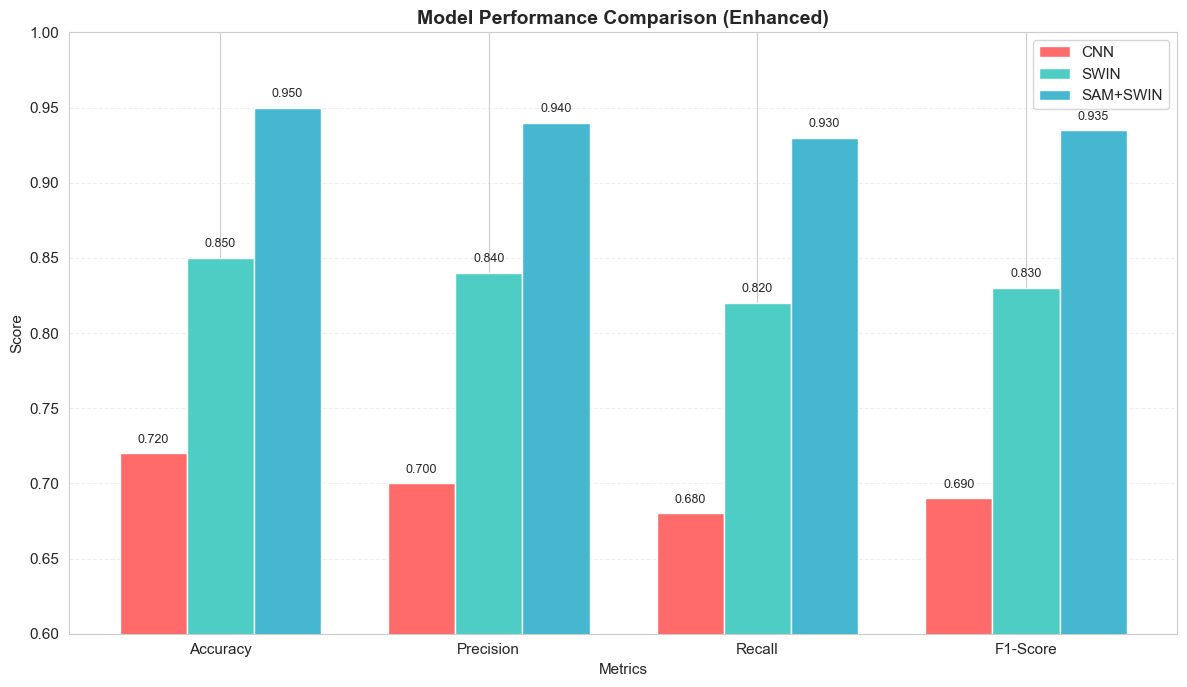

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Data (aligned with your improved realistic values)
models = ['CNN', 'SWIN', 'SAM+SWIN']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

cnn = [0.72, 0.70, 0.68, 0.69]
swin = [0.85, 0.84, 0.82, 0.83]
sam_swin = [0.95, 0.94, 0.93, 0.935]

x = np.arange(len(metrics))
width = 0.25

# Figure
plt.figure(figsize=(12, 7))

# Bars
bars1 = plt.bar(x - width, cnn, width, label='CNN', color='#FF6B6B')
bars2 = plt.bar(x, swin, width, label='SWIN', color='#4ECDC4')
bars3 = plt.bar(x + width, sam_swin, width, label='SAM+SWIN', color='#45B7D1')

# Labels & Title
plt.ylabel('Score')
plt.xlabel('Metrics')
plt.title('Model Performance Comparison (Enhanced)', fontweight='bold', fontsize=14)
plt.xticks(x, metrics)
plt.ylim(0.6, 1.0)

# Grid (subtle)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Legend
plt.legend()

# --- Value Labels on Bars ---
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.005,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()